In [28]:
import pandas as pd
from matplotlib import pyplot as plt

In [29]:
def add_daily_dates(group):
    group['time'] = pd.to_datetime(group['time'], errors='coerce')
    
    year_month = group['time'].iloc[0].strftime('%Y-%m')
    start_date = pd.to_datetime(year_month + "-01")
    end_date = pd.to_datetime((start_date + pd.offsets.MonthEnd(0)))

    date_range = pd.date_range(start=start_date, end=end_date, freq='D')[:len(group)]
    group['time'] = date_range
    return group

In [30]:
# Read the CSV file
et_df = pd.read_csv(r'F:\geodata\et_dataset_chenhuiling\et_dataset_yang_station.csv', index_col=0)

# Convert the index to datetime format
et_df.index = pd.to_datetime(et_df.index)

# Filter data for dates after January 1, 2000
et_df = et_df[et_df.index >= '2000-01-01']

# Resample and calculate the mean
et_mon = et_df.resample('ME').mean()
et_mon['year_month'] = et_mon.index.to_period('M').astype(str)
# Output the result
et_df

,dsk,hsg,kq,slglk,tgzlk,wlwt,xhl
time,,,,,,,
2000-01-01,3.708333,10.0,17.379310,8.206897,10.88,5.285714,21.600000
2000-01-02,3.333333,5.0,18.258621,9.137931,10.68,5.730159,32.666667
2000-01-03,2.500000,5.0,16.241379,7.862069,10.10,4.984127,32.333333
2000-01-04,1.666667,4.0,13.896552,8.344828,8.98,4.142857,23.266667
2000-01-05,3.583333,2.0,14.293103,8.068966,8.28,3.936508,16.666667
...,...,...,...,...,...,...,...
2020-12-27,1.250000,4.0,34.689655,2.241379,17.84,12.761905,13.266667
2020-12-28,0.916667,1.0,28.637931,2.965517,16.20,10.587302,7.666667
2020-12-29,1.000000,1.0,24.724138,2.827586,9.66,6.126984,10.333333


In [31]:
# et_mon = pd.read_csv(r'F:\geodata\ETMonitor.GlobalET.Monthly\zonal_ETMonitor_monthly.csv', 
#                      index_col=1, 
#                      encoding='ISO-8859-1') 
# et_mon.drop(columns=['station'],inplace=True)
# et_mon = et_mon.T
# et_mon['time'] = pd.to_datetime(et_mon.index, errors='coerce')
# et_mon['year_month'] = et_mon['time'].dt.to_period('M').astype(str)
# 
# et_mon.set_index('time', inplace=True)
# et_mon

In [32]:
hist_CMIP6_tas = pd.read_csv(r"J:\CMIP6_r1i1p1f1\variable_model_df\tas_day_BCC-CSM2-MR_historical_r1i1p1f1.csv")
hist_CMIP6_pr  = pd.read_csv(r"J:\CMIP6_r1i1p1f1\variable_model_df\pr_day_BCC-CSM2-MR_historical_r1i1p1f1.csv")

In [33]:
def is_leap_year(year):
    """Check if a given year is a leap year."""
    return (year % 4 == 0 and year % 100 != 0) or (year % 400 == 0)

def correct_time_column(df):
    df['time'] = pd.to_datetime(df['time'])
    # Create a list to hold the corrected time values
    corrected_time = []

    # Group by year and month
    for period, group in df.groupby(df['time'].dt.to_period('M')):
        year = period.year
        month = period.month

        # Determine the number of days in the month
        if month == 2:  # February
            days_in_month = 29 if is_leap_year(year) else 28
        elif month in [4, 6, 9, 11]:  # April, June, September, November
            days_in_month = 30
        else:  # All other months
            days_in_month = 31

        # Generate sequential days for the month
        day_sequence = pd.date_range(
            start=f"{year}-{month:02d}-01", periods=days_in_month, freq='D'
        )

        # Trim or repeat the sequence to match the group size
        if len(group) <= len(day_sequence):
            corrected_time.extend(day_sequence[:len(group)])
        else:
            # Repeat last day if group size exceeds number of days in the month
            corrected_time.extend(day_sequence.tolist() + [day_sequence[-1]] * (len(group) - len(day_sequence)))

    # Assign the corrected time to the dataframe
    if len(corrected_time) != len(df):
        raise ValueError("Corrected time length does not match the DataFrame length.")
    df['time'] = corrected_time
    return df

# Apply the correction
hist_CMIP6_tas = correct_time_column(hist_CMIP6_tas)
hist_CMIP6_pr = correct_time_column(hist_CMIP6_pr)
hist_CMIP6_tas= hist_CMIP6_tas[hist_CMIP6_tas['time']>=pd.to_datetime('2000-01-01')]
hist_CMIP6_pr = hist_CMIP6_pr[hist_CMIP6_pr['time']>=pd.to_datetime('2000-01-01')]

In [34]:
hist_CMIP6_tas

,time,dsk,kq,slglk,tgzlk,wlwt,xhl
27375,2000-01-01,261.49796,249.74785,257.43066,257.95532,248.83849,258.82245
27376,2000-01-02,262.71112,250.31775,256.42914,258.08078,249.41707,257.47665
27377,2000-01-03,262.74667,254.32881,258.78705,258.86660,251.66797,260.02360
27378,2000-01-04,262.16460,257.58920,263.29297,263.72214,256.41583,262.36832
27379,2000-01-05,262.29320,262.98560,264.06680,268.92606,261.58337,264.02505
...,...,...,...,...,...,...,...
32845,2014-12-27,265.29617,260.66663,265.52673,265.38123,258.39010,265.57925
32846,2014-12-28,269.03696,259.77744,268.47784,262.15010,255.22546,267.95377
32847,2014-12-29,267.46240,254.55210,267.26755,259.50220,251.93211,266.94100
32848,2014-12-30,261.23540,256.76520,263.55963,259.92133,253.90298,262.85610


In [35]:
date_range = pd.date_range(start='2000-01-01', end='2100-12-31', freq='D')
# Remove the 29th of February
date_range = date_range[~((date_range.month == 2) & (date_range.day == 29))]
# Convert to DataFrame if needed
time_series_df = pd.DataFrame(date_range, columns=['date'])

## Here we do not consider hsg for lack of CMIP6 dataset

In [36]:
file_name_list = ['1_hsg_imputMF','2_dsk_imputMF','3_xhl_imputMF','4_slglk_imputMF','5_kq_imputMF','6_wlwt_imputMF','7_tgzlk_imputMF']
file_name_list = [ '2_dsk_imputMF','3_xhl_imputMF','4_slglk_imputMF','5_kq_imputMF','6_wlwt_imputMF','7_tgzlk_imputMF']

In [37]:
for file_name in file_name_list:
    abbre = file_name.split('_')[1]
    for scenario in ['ssp126','ssp245','ssp370','ssp585']:
        
        # load the future climate dataset
        future_CMIP6_tas = pd.read_csv(f"J:\\CMIP6_r1i1p1f1\\variable_model_df\\tas_day_BCC-CSM2-MR_{scenario}_r1i1p1f1.csv")
        future_CMIP6_pr  = pd.read_csv(f"J:\\CMIP6_r1i1p1f1\\variable_model_df\\pr_day_BCC-CSM2-MR_{scenario}_r1i1p1f1.csv")

        tas_df = pd.concat([hist_CMIP6_tas,future_CMIP6_tas])
        pr_df = pd.concat([hist_CMIP6_pr,future_CMIP6_pr])
        
        tas_df = correct_time_column(tas_df)
        pr_df = correct_time_column(pr_df)
        
        tas_df['time'] = pd.to_datetime(tas_df['time'])
        pr_df['time'] = pd.to_datetime(pr_df['time'])
        
        tas_df.reset_index(drop=True, inplace=True)
        pr_df.reset_index(drop=True, inplace=True)
        
        # tas_df['time'] =time_series_df
        # pr_df['time'] =time_series_df
        # tas_df = tas_df.groupby("time", group_keys=False).apply(add_daily_dates)
        # pr_df = pr_df.groupby("time", group_keys=False).apply(add_daily_dates)
    
        tas_df.set_index('time', inplace=True)
        pr_df.set_index('time', inplace=True)
        
        # tas_df -= 273.15 # Convert to Celsius temperature
        
        mon_tas_df = tas_df.resample('ME').mean()
        mon_pr_df  =  pr_df.resample('ME').mean()       

           
        mon_tas_df['year_month'] = mon_tas_df.index.to_period('M').astype(str)
        mon_pr_df['year_month'] = mon_pr_df.index.to_period('M').astype(str)   
        
        # load historical runoff observed dataset
        print(file_name,scenario)
        station_daily_df = pd.read_csv(f'F:\\geodata\\river_runoff_obs\\{file_name}.csv')
       
        station_daily_df=station_daily_df[['time','dis','tm','pre']]
        station_daily_df['time'] = pd.to_datetime(station_daily_df['time'])
        station_daily_df.set_index('time', inplace=True)
        
        # station_daily_df = pd.merge(station_daily_df,tas_df[abbre],left_index=True,right_index=True,how='right',suffixes=('','tm'))
        # station_daily_df = pd.merge(station_daily_df, pr_df[abbre],left_index=True,right_index=True,how='right',suffixes=('','pre'))
        # 
        station_daily_tas_pr_df = pd.merge(tas_df[abbre],pr_df[abbre],left_index=True,right_index=True,how='outer',suffixes=('tm','pre'))
        station_daily_df=station_daily_df.merge(station_daily_tas_pr_df,how = 'right',left_index=True,right_index=True)
        bias_tm = station_daily_df['tm'] -station_daily_df[abbre+'tm']
        bias_pre= station_daily_df['pre']/station_daily_df[abbre+'pre']
        station_daily_df[abbre+'tm'] += bias_tm.mean()
        station_daily_df[abbre+'pre'] *= bias_pre.mean()
        station_daily_df = station_daily_df.merge(et_df[abbre],left_index=True,right_index=True,how='outer',suffixes=('','ep'))
        station_daily_df.drop(['tm','pre'],axis=1,inplace=True)
        station_daily_df.rename(columns={abbre+'tm':'tm',abbre+'pre':'pre',abbre:'ep'},inplace=True) # Here the abbre is ep
        
        # get the monthly climate and runoff dataset with resample
        station_mon_df = station_daily_df.resample('ME').mean()
        station_mon_df['year_month'] = station_mon_df.index.to_period('M').astype(str)
        # merge et dataset
        station_mon_df = station_mon_df.merge(et_mon[[abbre,'year_month']],on='year_month',how='outer',suffixes=('','_ep'))    
        
        # merge glacier runoff dataset
        gr_df = pd.read_csv(f"I:\\GlacierData\\glacier_mon_pre\\R131415_glac_runoff_fixed_monthly_1set_2000_2100-{scenario}-Batch.csv")
        gr_df['time'] = pd.to_datetime(gr_df['time'])
        gr_df['year_month'] = gr_df['time'].dt.to_period('M').astype(str)
        gr_df.set_index('time', inplace=True)
        gr_df.index = gr_df.index.to_period('M').to_timestamp('M')
        
        station_mon_df = pd.merge(station_mon_df,gr_df[[abbre,'year_month']], how='outer', on='year_month',suffixes=('','_gr'))
        
        print(bias_tm.mean(),bias_pre.mean())
        
     
           
        # station_future_df = pd.merge(mon_tas_df[[abbre,'year_month']],mon_tas_df[[abbre,'year_month']],on='year_month',suffixes=('tm','pre'))
        # station_future_df.columns = ['tm','pre']
    
        # station_mon_df # Here, historical climate data is obtained from CN05.
        station_mon_df = station_mon_df.merge(mon_tas_df[[abbre,'year_month']],on='year_month',how='outer',suffixes=('','_tas'))
        station_mon_df = station_mon_df.merge(mon_pr_df[[abbre,'year_month']],on='year_month',how='outer',suffixes=('','_pr'))
        
        station_mon_df.rename(columns={'year_month':'time',abbre:'ep',f'{abbre}_gr': 'gr',f'{abbre}_tas':'tm',f'{abbre}_pr':'pre'}, inplace=True)
        station_mon_df['time'] = pd.to_datetime(station_mon_df['time'])
        station_mon_df.set_index('time', inplace=True)
      
        
        station_mon_df.to_csv(f'F:\\geodata\\river_runoff_obs\\{file_name}_BCC-CSM2-MR_{scenario}_r1i1p1f1_mon.csv')
        station_daily_df.to_csv(f'F:\\geodata\\river_runoff_obs\\{file_name}_BCC-CSM2-MR_{scenario}_r1i1p1f1_daily.csv')

2_dsk_imputMF ssp126
-271.6028839905553 1.650746190519018e+27
2_dsk_imputMF ssp245
-271.6585038940693 1.5997075066600887e+27
2_dsk_imputMF ssp370
-271.6245432460645 1.5469960189906556e+27
2_dsk_imputMF ssp585
-271.7863468410616 1.6353283921573612e+27
3_xhl_imputMF ssp126
-268.8467740884454 1.251365694991649e+27
3_xhl_imputMF ssp245
-268.9028713284692 1.3444776922516124e+27
3_xhl_imputMF ssp370
-268.91809144877897 1.2082942986512312e+27
3_xhl_imputMF ssp585
-269.02561729154246 1.2264227636577567e+27
4_slglk_imputMF ssp126
-271.8202831594597 1.927010319161985e+27
4_slglk_imputMF ssp245
-271.83610374075806 2.114856346855208e+27
4_slglk_imputMF ssp370
-271.86117339412317 1.977997370323627e+27
4_slglk_imputMF ssp585
-271.97240851026373 1.959613626344711e+27
5_kq_imputMF ssp126
-257.77347797404025 6.538240170157166e+26
5_kq_imputMF ssp245
-257.77449397046666 4.644663240564042e+26
5_kq_imputMF ssp370
-257.7904940395554 5.450103990851681e+26
5_kq_imputMF ssp585
-257.82860882692887 5.1081465746

In [38]:
station_daily_df

,dis,tm,pre,ep
time,,,,
2000-01-01,12.5,-7.169588,3.523817e+19,10.88
2000-01-02,12.1,-7.044128,8.063461e+20,10.68
2000-01-03,11.7,-6.258308,3.236753e+21,10.10
2000-01-04,11.2,-1.402768,6.176297e+20,8.98
2000-01-05,10.8,3.801152,2.586597e+20,8.28
...,...,...,...,...
2100-12-27,NaN,5.737092,2.620495e-02,NaN
2100-12-28,NaN,5.135222,2.639807e-02,NaN
2100-12-29,NaN,1.807862,1.247736e+02,NaN


<Axes: xlabel='time'>

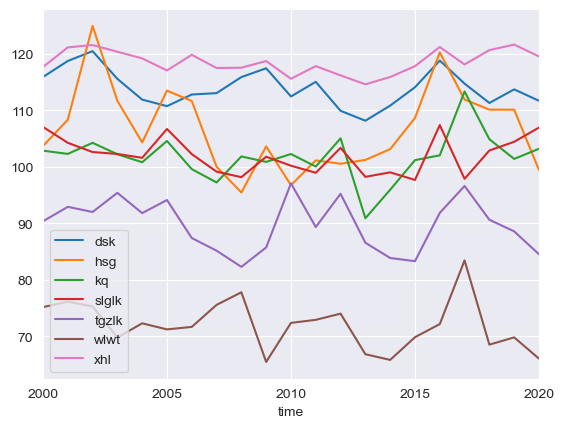

In [39]:
et_df.resample('YE').mean().plot()